In [46]:
# Libraries

import os, math, re
import pandas as pd
import numpy as np
from urllib.parse import urlparse
from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42


In [47]:
# Loading Dataset

DATA_PATH = "malicious_phish.csv"   #

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Columns:", df.columns.tolist())
# Try to detect `url` and `type` column names automatically:
if 'url' not in df.columns:
    for c in df.columns:
        if 'url' in c.lower():
            df = df.rename(columns={c: 'url'})
            break
if 'type' not in df.columns:
    for c in df.columns:
        if any(x in c.lower() for x in ['type','class','target']):
            df = df.rename(columns={c: 'type'})
            break

# Keep only URL+type if present:
df = df[[c for c in ['url','type'] if c in df.columns]].dropna().reset_index(drop=True)
print("After selection, shape:", df.shape)
print(df['type'].value_counts())

# sample for fast iteration (e.g., 10k)
sample_df = df.sample(n=min(10000, len(df)), random_state=RANDOM_STATE)
sample_df.head()


Columns: ['url', 'type']
After selection, shape: (651191, 2)
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


,url,type
536448,http://37.49.226.178/deusbins/deus.sh4,malware
40630,medical-dictionary.thefreedictionary.com/Galt+...,benign
630496,www.jscape.com/sshfactory/,phishing
426724,http://www.wsnc.org.au/component/jcalpro/view/983,defacement
184034,virtualtourist.com/travel/North_America/Canada...,benign


In [48]:
# Lable and Train/test split

le = LabelEncoder()
y = le.fit_transform(sample_df['type'].astype(str))
X = sample_df['url'].astype(str).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train size:", len(X_train), "Test size:", len(X_test))
print("Classes:", list(le.classes_))


Train size: 8000 Test size: 2000
Classes: ['benign', 'defacement', 'malware', 'phishing']


In [49]:
# feature extractor and tokeniser (copy from script)
IP_IN_DOMAIN = re.compile(r'^(?:\d{1,3}\.){3}\d{1,3}$')

def has_ip(url):
    try:
        hostname = urlparse(url if url.startswith('http') else 'http://' + url).hostname or ''
        return bool(IP_IN_DOMAIN.search(hostname))
    except Exception:
        return False

def count_digits(s):
    return sum(c.isdigit() for c in s)

def tokenise_url(url):
    url = (url or "").lower()
    tokens = re.split(r'[^a-z0-9]', url)
    tokens = [t for t in tokens if t]
    return " ".join(tokens)

def shannon_entropy(s):
    if not s:
        return 0.0
    counts = Counter(s)
    probs = [float(c) / len(s) for c in counts.values()]
    return -sum(p * math.log2(p) for p in probs)

class URLFeatureExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        rows = []
        for url in X:
            if pd.isna(url): url = ""
            parsed = urlparse(url if str(url).startswith('http') else 'http://' + str(url))
            hostname = parsed.hostname or ''
            path = parsed.path or ''
            query = parsed.query or ''
            url_text = str(url)
            features = [
                len(url_text),
                len(hostname),
                len(path),
                len(query),
                count_digits(url_text),
                url_text.count('-'),
                url_text.count('_'),
                url_text.count('.'),
                int(has_ip(url_text)),
                hostname.count('.') if hostname else 0,
                len(tokenise_url(url_text).split()),
                shannon_entropy(url_text),
                int(parsed.scheme == 'https'),
            ]
            rows.append(features)
        return np.array(rows)

    def get_feature_names(self):
        return ['url_len','hostname_len','path_len','query_len','count_digits','count_hyphens',
                'count_underscores','count_dots','has_ip','num_subdomains','tokens_len','entropy','has_https']


In [50]:
# pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer

def extract_tokens(X):
    return [tokenise_url(x) for x in X]

numeric_pipeline = Pipeline([
    ('url_feats', URLFeatureExtractor()),
    ('scaler', StandardScaler())
])

text_pipeline = Pipeline([
    ('tok', FunctionTransformer(extract_tokens, validate=False)),
    ('tfidf', TfidfVectorizer(ngram_range=(1,3), max_features=20000))
])

full_features = FeatureUnion([
    ('num', numeric_pipeline),
    ('txt', text_pipeline)
])


In [51]:
# quick prototype with LightGBM (fast) or RandomForest fallback

try:
    import lightgbm as lgb
    clf = lgb.LGBMClassifier(objective='multiclass', num_class=len(le.classes_), n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced')
    print("Using LightGBM")
except Exception:
    from sklearn.ensemble import RandomForestClassifier
    clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)
    print("Using RandomForest")

pipeline = Pipeline([
    ('features', full_features),
    ('clf', clf)
])

# Fit on the small sample
pipeline.fit(X_train, y_train)


Using LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013499 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14640
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 628
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


,steps,"[('features', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('num', ...), ('txt', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,copy,True
,with_mean,True


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

      benign       0.97      0.97      0.97      1325
  defacement       0.94      0.96      0.95       287
     malware       0.93      0.85      0.89       103
    phishing       0.81      0.84      0.83       285

    accuracy                           0.94      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.94      0.94      0.94      2000



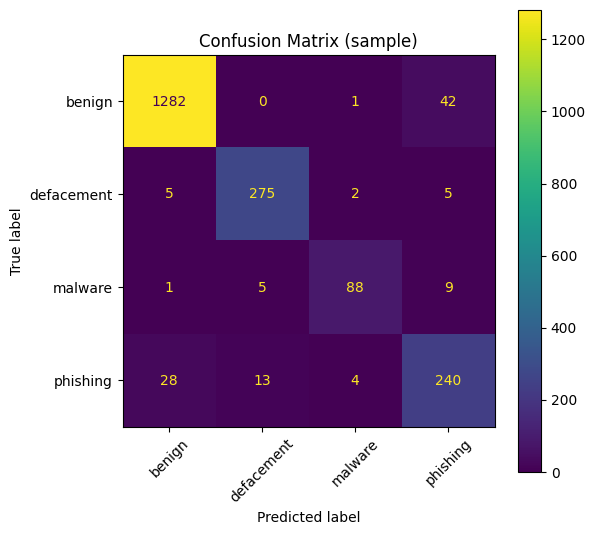

In [52]:
#evaluation

y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix (sample)")
plt.show()


In [53]:
# feature importance for LGB


if hasattr(pipeline.named_steps['clf'], 'feature_importances_'):
    # We need to get feature names (numeric + tfidf top features)
    # Numeric names:
    num_names = URLFeatureExtractor().get_feature_names()
    # For TF-IDF, grab top n feature names
    tfidf = pipeline.named_steps['features'].transformer_list[1][1].named_steps['tfidf']
    tfidf_names = tfidf.get_feature_names_out()
    # Combined:
    feat_names = list(num_names) + list(tfidf_names)
    importances = pipeline.named_steps['clf'].feature_importances_
    top_idx = np.argsort(importances)[-30:][::-1]
    for i in top_idx[:20]:
        print(f"{i}: {feat_names[i]} -> {importances[i]}")
else:
    print("Feature importance not available for this classifier.")


11: entropy -> 2291
0: url_len -> 1705
2: path_len -> 1615
1: hostname_len -> 1524
9112: com -> 1343
12396: http -> 1178
4: count_digits -> 733
10: tokens_len -> 706
5: count_hyphens -> 642
12354: html -> 552
19405: www -> 537
7: count_dots -> 469
12343: htm -> 439
12814: http www -> 418
9: num_subdomains -> 397
16143: php -> 358
3: query_len -> 306
13013: https -> 295
15756: org -> 228
15201: net -> 227


In [54]:
# inspect wrong predictions

errors = []
for url, true, pred in zip(X_test, y_test, y_pred):
    if true != pred:
        errors.append((url, le.inverse_transform([true])[0], le.inverse_transform([pred])[0]))
errors[:10]   # first 10 errors to inspect


[('www.rakmill.com/cnf/1.htm', 'benign', 'phishing'),
 ('members.tripod.com/~Paralogy/index.html', 'phishing', 'benign'),
 ('http://www.nhdyyy.com/ww/?https:/secure.runescape.com/m=weblogin/loginform.ws',
  'phishing',
  'malware'),
 ('http://szgs.ru/object.php?object=ะก-\\320%9Fะฑ-ะฟ-\\320%93ะพ\\321%80ะตะปะพะฒะพ.html&sid=1',
  'defacement',
  'benign'),
 ('http://r...content-available-to-author-only...a.org/wiki/%D0%9C%D1%8D%D1%x80_%D0%..',
  'malware',
  'phishing'),
 ('http://www.spg-pneus.com/skyfall/280ae8fd9fa10a373325487622d9a089/validation.html?g4d3bdOsiuarHDdBl0bEP6dBVy_wP1WJ6XZDh7nemRp9bv2mHJ0HYZaZV6xWExsS',
  'phishing',
  'defacement'),
 ('http://player.polyv.net/videos/3ee850a192d81e2c58f65f9ff5eb0f32_3.swf',
  'malware',
  'phishing'),
 ('http://xossip.com/forumdisplay.php?s=1a0185aef96dc82d1f523a00d7134802&f=63&sort=dateline',
  'benign',
  'phishing'),
 ('metro.jaygees.net/english/awards_eng.html', 'benign', 'phishing'),
 ('bioweb.pasteur.fr/seqanal/motif/sam-uk.html', 

In [56]:
# full training (careful, this reads all rows)
full_df = df  # use df, not sample_df
X_full = full_df['url'].astype(str).values
y_full = le.fit_transform(full_df['type'].astype(str))

X_train_full, X_val, y_train_full, y_val = train_test_split(X_full, y_full, test_size=0.1, stratify=y_full, random_state=RANDOM_STATE)

# Fit TF-IDF on all training text: we should fit the pipeline normally.
# If using LightGBM with early stopping, call fit with eval_set and early_stopping_rounds

pipeline_full = Pipeline([
    ('features', full_features),
    ('clf', lgb.LGBMClassifier(objective='multiclass', num_class=len(le.classes_), n_estimators=2000, learning_rate=0.05, random_state=RANDOM_STATE, class_weight='balanced'))
])

# Fit with early stopping (LightGBM supports eval_set and eval_metric)
pipeline_full.fit(
    X_train_full, y_train_full,
    clf__eval_set=[(X_val, y_val)],
    clf__eval_metric='multi_logloss',
    clf__early_stopping_rounds=50
)

# Save model
joblib.dump(pipeline_full, "phishing_pipeline_full.joblib")


ValueError: Invalid IPv6 URL

In [ ]:
# example param grid for RandomizedSearchCV (use on a smaller subset)

params = {
    "clf__n_estimators": [100, 300, 800],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__max_depth": [-1, 6, 10],
    "clf__num_leaves": [31, 64, 128]
}

rs = RandomizedSearchCV(pipeline, params, n_iter=12, scoring='f1_macro', n_jobs=1, cv=3, verbose=2, random_state=RANDOM_STATE)
rs.fit(X_train, y_train)
print("Best params:", rs.best_params_)
print("Best CV score:", rs.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 376
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=300, clf__num_leaves=31; total time=   4.4s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006017 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9370
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 384
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=300, clf__num_leaves=31; total time=   4.3s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9468
[LightGBM] [Info] Number of data points in the train set: 5334, number of used features: 399
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=300, clf__num_leaves=31; total time=   3.9s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006059 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 376
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=-1, clf__n_estimators=100, clf__num_leaves=31; total time=   2.3s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005970 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9370
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 384
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=-1, clf__n_estimators=100, clf__num_leaves=31; total time=   2.4s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006663 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9468
[LightGBM] [Info] Number of data points in the train set: 5334, number of used features: 399
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=-1, clf__n_estimators=100, clf__num_leaves=31; total time=   2.2s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 376
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=10, clf__n_estimators=300, clf__num_leaves=64; total time=   5.8s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006123 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9370
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 384
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=10, clf__n_estimators=300, clf__num_leaves=64; total time=   5.6s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9468
[LightGBM] [Info] Number of data points in the train set: 5334, number of used features: 399
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=10, clf__n_estimators=300, clf__num_leaves=64; total time=   5.3s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007097 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 376
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=300, clf__num_leaves=64; total time=   6.9s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007013 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9370
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 384
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=300, clf__num_leaves=64; total time=   6.4s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006345 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9468
[LightGBM] [Info] Number of data points in the train set: 5334, number of used features: 399
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=300, clf__num_leaves=64; total time=   5.8s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006528 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 376
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=10, clf__n_estimators=100, clf__num_leaves=31; total time=   2.2s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9370
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 384
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=10, clf__n_estimators=100, clf__num_leaves=31; total time=   2.2s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9468
[LightGBM] [Info] Number of data points in the train set: 5334, number of used features: 399
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=10, clf__n_estimators=100, clf__num_leaves=31; total time=   2.3s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006203 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 376
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=100, clf__num_leaves=64; total time=   3.1s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006531 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9370
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 384
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=100, clf__num_leaves=64; total time=   3.1s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013898 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9468
[LightGBM] [Info] Number of data points in the train set: 5334, number of used features: 399
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=100, clf__num_leaves=64; total time=   3.0s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 376
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=6, clf__n_estimators=100, clf__num_leaves=64; total time=   2.1s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007223 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9370
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 384
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=6, clf__n_estimators=100, clf__num_leaves=64; total time=   2.1s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007740 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9468
[LightGBM] [Info] Number of data points in the train set: 5334, number of used features: 399
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=6, clf__n_estimators=100, clf__num_leaves=64; total time=   2.0s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 376
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.1, clf__max_depth=6, clf__n_estimators=800, clf__num_leaves=64; total time=   5.2s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005988 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9370
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 384
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.1, clf__max_depth=6, clf__n_estimators=800, clf__num_leaves=64; total time=   5.1s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006581 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9468
[LightGBM] [Info] Number of data points in the train set: 5334, number of used features: 399
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.1, clf__max_depth=6, clf__n_estimators=800, clf__num_leaves=64; total time=   4.9s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005971 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 376
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=-1, clf__n_estimators=300, clf__num_leaves=64; total time=   6.5s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9370
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 384
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=-1, clf__n_estimators=300, clf__num_leaves=64; total time=   6.5s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006946 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9468
[LightGBM] [Info] Number of data points in the train set: 5334, number of used features: 399
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=-1, clf__n_estimators=300, clf__num_leaves=64; total time=   5.7s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 376
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=6, clf__n_estimators=300, clf__num_leaves=31; total time=   3.4s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007386 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9370
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 384
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=6, clf__n_estimators=300, clf__num_leaves=31; total time=   3.6s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006432 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9468
[LightGBM] [Info] Number of data points in the train set: 5334, number of used features: 399
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.01, clf__max_depth=6, clf__n_estimators=300, clf__num_leaves=31; total time=   3.3s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 376
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=10, clf__n_estimators=300, clf__num_leaves=64; total time=   4.8s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006145 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9370
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 384
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=10, clf__n_estimators=300, clf__num_leaves=64; total time=   4.9s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9468
[LightGBM] [Info] Number of data points in the train set: 5334, number of used features: 399
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=10, clf__n_estimators=300, clf__num_leaves=64; total time=   4.3s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005903 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 376
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=800, clf__num_leaves=31; total time=   8.5s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9370
[LightGBM] [Info] Number of data points in the train set: 5333, number of used features: 384
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=800, clf__num_leaves=31; total time=   8.0s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006358 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9468
[LightGBM] [Info] Number of data points in the train set: 5334, number of used features: 399
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warn

C:\Users\aakas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=800, clf__num_leaves=31; total time=   7.4s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010679 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14640
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 628
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War